**Fake News Detection**

In [1]:
# STEP 1 - Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import string
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

print('All libraries imported successfully!')

All libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ashok\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ashok\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ashok\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
# STEP 2 - Load Dataset
# Download from: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
# Place Fake.csv and True.csv in the same folder as this notebook

fake = pd.read_csv('Fake.csv')
real = pd.read_csv('True.csv')

fake['label'] = 1   # 1 = Fake
real['label'] = 0   # 0 = Real

df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print('Fake news shape :', fake.shape)
print('Real news shape :', real.shape)
print('Combined shape  :', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Fake news shape : (23481, 5)
Real news shape : (21417, 5)
Combined shape  : (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


In [3]:
# STEP 3 - EDA
print('Dataset Info:')
print('-'*40)
print(f'Total articles : {len(df):,}')
print(f'Fake news      : {len(fake):,} ({len(fake)/len(df)*100:.1f}%)')
print(f'Real news      : {len(real):,} ({len(real)/len(df)*100:.1f}%)')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicates     : {df.duplicated().sum()}')
print(f'\nAvg word count (Fake): {fake["text"].apply(lambda x: len(str(x).split())).mean():.0f}')
print(f'Avg word count (Real): {real["text"].apply(lambda x: len(str(x).split())).mean():.0f}')

Dataset Info:
----------------------------------------
Total articles : 44,898
Fake news      : 23,481 (52.3%)
Real news      : 21,417 (47.7%)
Missing values : 0
Duplicates     : 209

Avg word count (Fake): 423
Avg word count (Real): 386


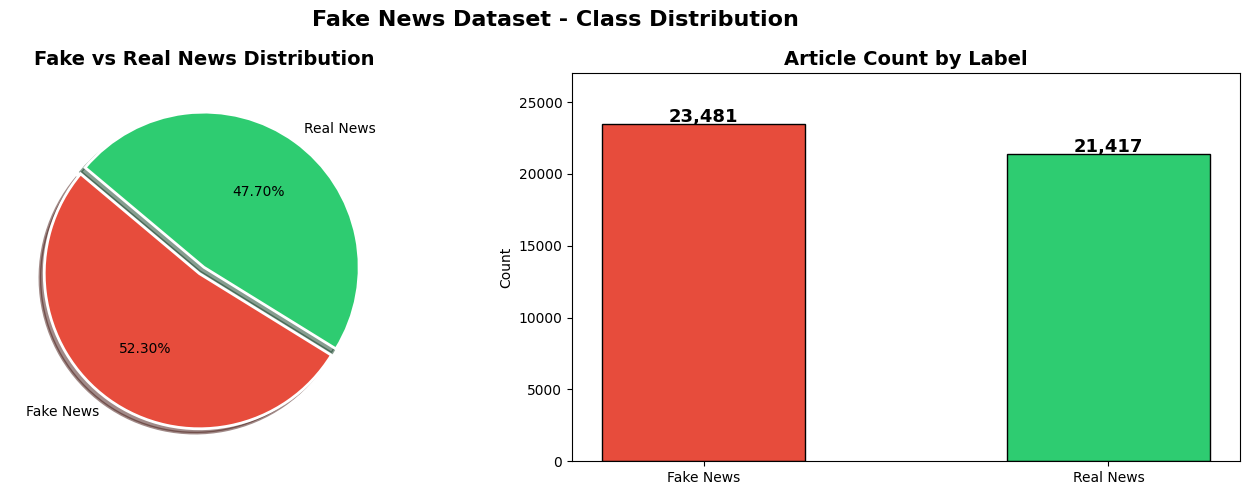

Saved: 01_class_distribution.png


In [4]:
# STEP 3b - Pie Chart + Bar Chart
label_counts = df['label'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    label_counts,
    labels=['Fake News', 'Real News'],
    autopct='%1.2f%%',
    colors=['#E74C3C', '#2ECC71'],
    startangle=140,
    explode=(0.05, 0),
    shadow=True,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
axes[0].set_title('Fake vs Real News Distribution', fontsize=14, fontweight='bold')

bars = axes[1].bar(['Fake News','Real News'], label_counts.values,
    color=['#E74C3C','#2ECC71'], edgecolor='black', width=0.5)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
        f'{bar.get_height():,}', ha='center', fontsize=13, fontweight='bold')
axes[1].set_title('Article Count by Label', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, label_counts.max()*1.15)

plt.suptitle('Fake News Dataset - Class Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_class_distribution.png')

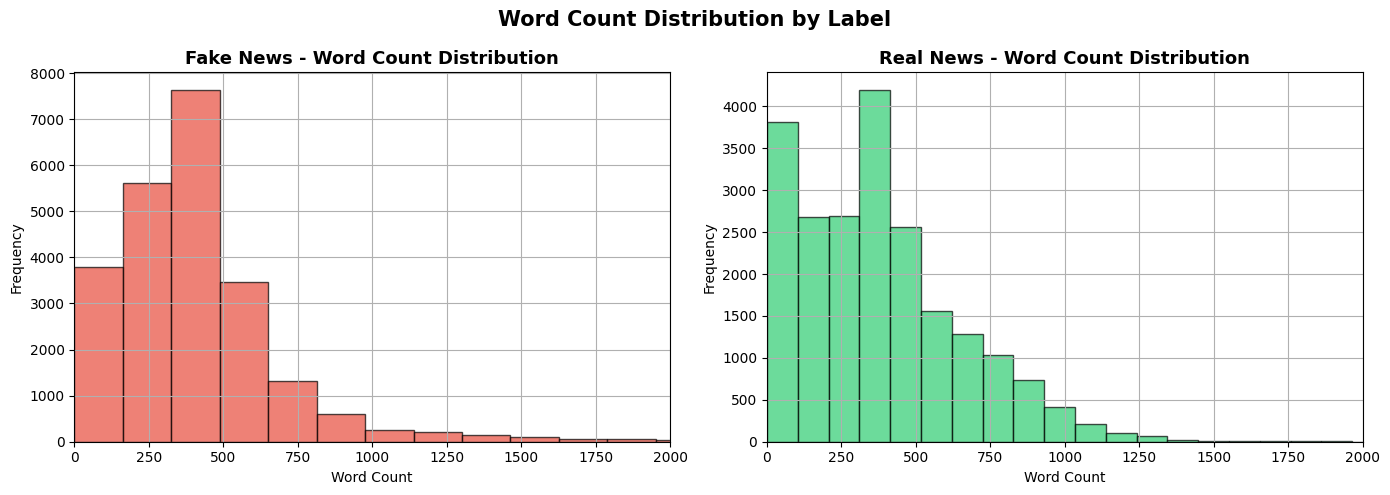

Saved: 02_word_count_distribution.png


In [5]:
# STEP 3c - Article Word Count Distribution
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['label']==1]['word_count'].hist(bins=50, ax=axes[0], color='#E74C3C', alpha=0.7, edgecolor='black')
axes[0].set_title('Fake News - Word Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 2000)

df[df['label']==0]['word_count'].hist(bins=50, ax=axes[1], color='#2ECC71', alpha=0.7, edgecolor='black')
axes[1].set_title('Real News - Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 2000)

plt.suptitle('Word Count Distribution by Label', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('02_word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_word_count_distribution.png')

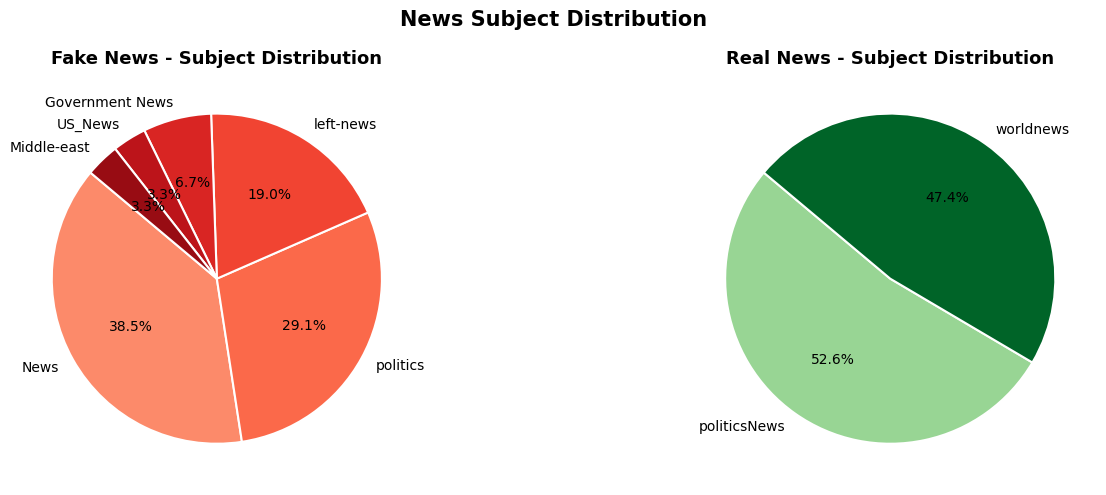

Saved: 03_subject_distribution.png


In [6]:
# STEP 3d - Top News Subjects/Subjects Pie
if 'subject' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    fake_subj = fake['subject'].value_counts().head(6)
    real_subj = real['subject'].value_counts().head(6)

    axes[0].pie(fake_subj, labels=fake_subj.index, autopct='%1.1f%%',
        startangle=140, colors=plt.cm.Reds(np.linspace(0.4,0.9,len(fake_subj))),
        wedgeprops={'edgecolor':'white','linewidth':1.5})
    axes[0].set_title('Fake News - Subject Distribution', fontsize=13, fontweight='bold')

    axes[1].pie(real_subj, labels=real_subj.index, autopct='%1.1f%%',
        startangle=140, colors=plt.cm.Greens(np.linspace(0.4,0.9,len(real_subj))),
        wedgeprops={'edgecolor':'white','linewidth':1.5})
    axes[1].set_title('Real News - Subject Distribution', fontsize=13, fontweight='bold')

    plt.suptitle('News Subject Distribution', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('03_subject_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 03_subject_distribution.png')
else:
    print('No subject column found - skipping subject chart')

In [7]:
# STEP 4 - Data Cleaning & Text Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)          # remove brackets
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # remove URLs
    text = re.sub(r'<.*?>+', '', text)            # remove HTML
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # remove punctuation
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)          # remove words with numbers
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print('Cleaning text... (this may take 1-2 minutes)')
df['clean_text'] = df['text'].apply(clean_text)
print('Text cleaning done!')
print('\nSample cleaned text:')
print(df['clean_text'].iloc[0][:300])

Cleaning text... (this may take 1-2 minutes)
Text cleaning done!

Sample cleaned text:
century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement circuit court washingto


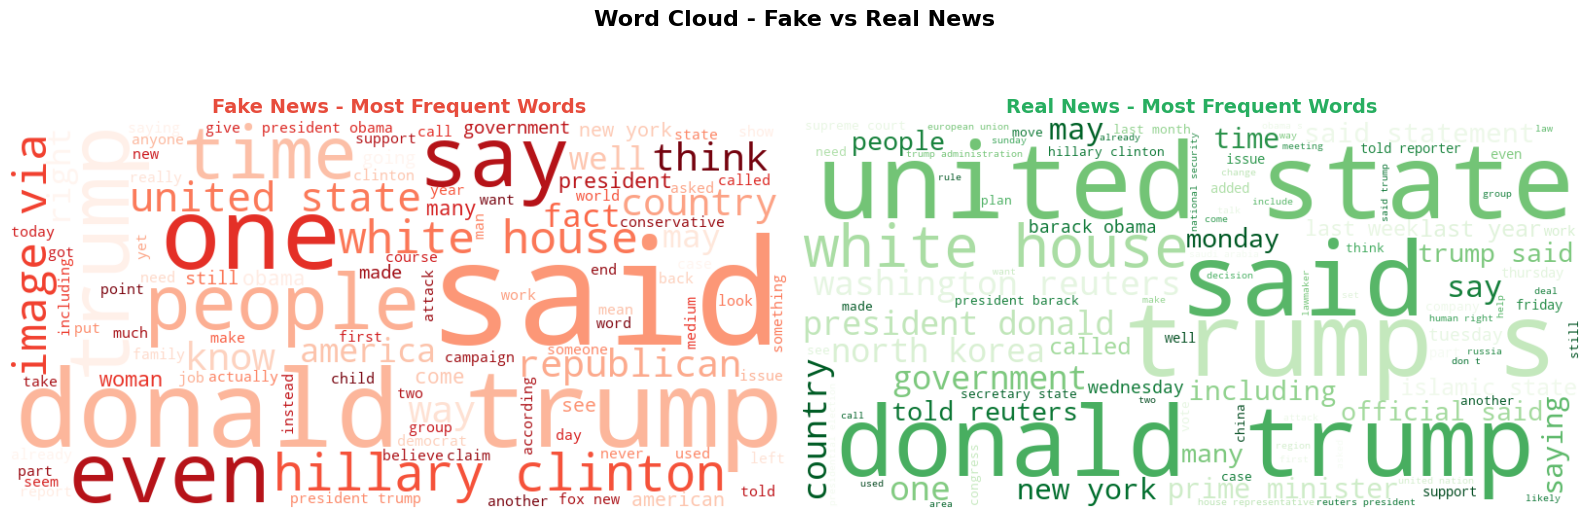

Saved: 04_wordcloud.png


In [8]:
# STEP 4b - Word Cloud
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fake_text = ' '.join(df[df['label']==1]['clean_text'].tolist())
real_text = ' '.join(df[df['label']==0]['clean_text'].tolist())

wc_fake = WordCloud(width=800, height=400, background_color='white',
    colormap='Reds', max_words=100).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Fake News - Most Frequent Words', fontsize=14, fontweight='bold', color='#E74C3C')

wc_real = WordCloud(width=800, height=400, background_color='white',
    colormap='Greens', max_words=100).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Real News - Most Frequent Words', fontsize=14, fontweight='bold', color='#27AE60')

plt.suptitle('Word Cloud - Fake vs Real News', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('04_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_wordcloud.png')

In [9]:
# STEP 4c - TF-IDF Vectorization + Train/Test Split
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf  = tfidf.transform(X_test)

print(f'Training set   : {X_train_tf.shape[0]} samples')
print(f'Test set       : {X_test_tf.shape[0]} samples')
print(f'TF-IDF features: {X_train_tf.shape[1]:,}')

Training set   : 35918 samples
Test set       : 8980 samples
TF-IDF features: 10,000


Logistic Regression

In [10]:
# STEP 5 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_tf, y_train)

lr_pred = lr_model.predict(X_test_tf)
lr_prob = lr_model.predict_proba(X_test_tf)[:,1]

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)

print('='*45)
print('      LOGISTIC REGRESSION RESULTS')
print('='*45)
print(f'  Accuracy  : {lr_acc:.4f}')
print(f'  Precision : {lr_prec:.4f}')
print(f'  Recall    : {lr_rec:.4f}')
print(f'  F1-Score  : {lr_f1:.4f}')
print('='*45)
print(classification_report(y_test, lr_pred, target_names=['Real','Fake']))

      LOGISTIC REGRESSION RESULTS
  Accuracy  : 0.9882
  Precision : 0.9919
  Recall    : 0.9855
  F1-Score  : 0.9887
              precision    recall  f1-score   support

        Real       0.98      0.99      0.99      4284
        Fake       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



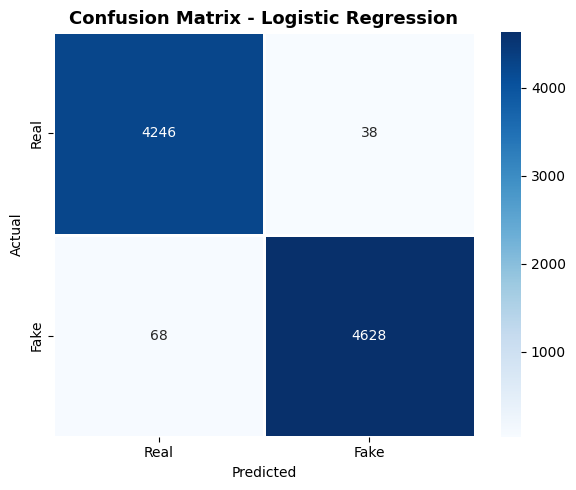

In [11]:
# Confusion Matrix - Logistic Regression
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d',
    cmap='Blues', xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake'], linewidths=1, linecolor='white')
plt.title('Confusion Matrix - Logistic Regression', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('05_cm_lr.png', dpi=150, bbox_inches='tight')
plt.show()

Decision Tree

In [12]:
# STEP 6 - Decision Tree
dt_model = DecisionTreeClassifier(max_depth=20, random_state=42, min_samples_split=10)
dt_model.fit(X_train_tf, y_train)

dt_pred = dt_model.predict(X_test_tf)
dt_prob = dt_model.predict_proba(X_test_tf)[:,1]

dt_acc  = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec  = recall_score(y_test, dt_pred)
dt_f1   = f1_score(y_test, dt_pred)

print('='*45)
print('         DECISION TREE RESULTS')
print('='*45)
print(f'  Accuracy  : {dt_acc:.4f}')
print(f'  Precision : {dt_prec:.4f}')
print(f'  Recall    : {dt_rec:.4f}')
print(f'  F1-Score  : {dt_f1:.4f}')
print('='*45)
print(classification_report(y_test, dt_pred, target_names=['Real','Fake']))

         DECISION TREE RESULTS
  Accuracy  : 0.9959
  Precision : 0.9972
  Recall    : 0.9949
  F1-Score  : 0.9961
              precision    recall  f1-score   support

        Real       0.99      1.00      1.00      4284
        Fake       1.00      0.99      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



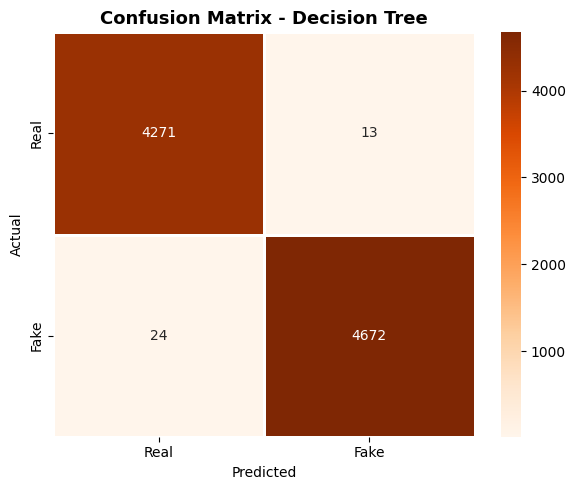

In [13]:
# Confusion Matrix - Decision Tree
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d',
    cmap='Oranges', xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake'], linewidths=1, linecolor='white')
plt.title('Confusion Matrix - Decision Tree', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('06_cm_dt.png', dpi=150, bbox_inches='tight')
plt.show()

Random Forest

In [14]:
# STEP 7 - Random Forest
rf_model = RandomForestClassifier(
    n_estimators=50, random_state=42,
    max_depth=20, n_jobs=-1, min_samples_split=10)
rf_model.fit(X_train_tf, y_train)

rf_pred = rf_model.predict(X_test_tf)
rf_prob = rf_model.predict_proba(X_test_tf)[:,1]

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec  = recall_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred)

print('='*45)
print('          RANDOM FOREST RESULTS')
print('='*45)
print(f'  Accuracy  : {rf_acc:.4f}')
print(f'  Precision : {rf_prec:.4f}')
print(f'  Recall    : {rf_rec:.4f}')
print(f'  F1-Score  : {rf_f1:.4f}')
print('='*45)
print(classification_report(y_test, rf_pred, target_names=['Real','Fake']))

          RANDOM FOREST RESULTS
  Accuracy  : 0.9953
  Precision : 0.9962
  Recall    : 0.9949
  F1-Score  : 0.9955
              precision    recall  f1-score   support

        Real       0.99      1.00      1.00      4284
        Fake       1.00      0.99      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



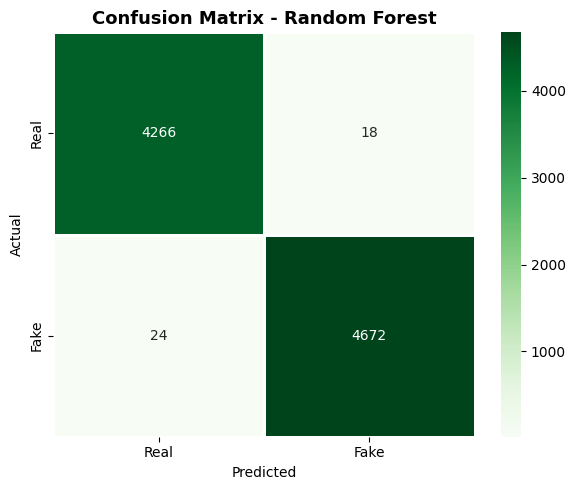

In [15]:
# Confusion Matrix - Random Forest
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d',
    cmap='Greens', xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake'], linewidths=1, linecolor='white')
plt.title('Confusion Matrix - Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('07_cm_rf.png', dpi=150, bbox_inches='tight')
plt.show()

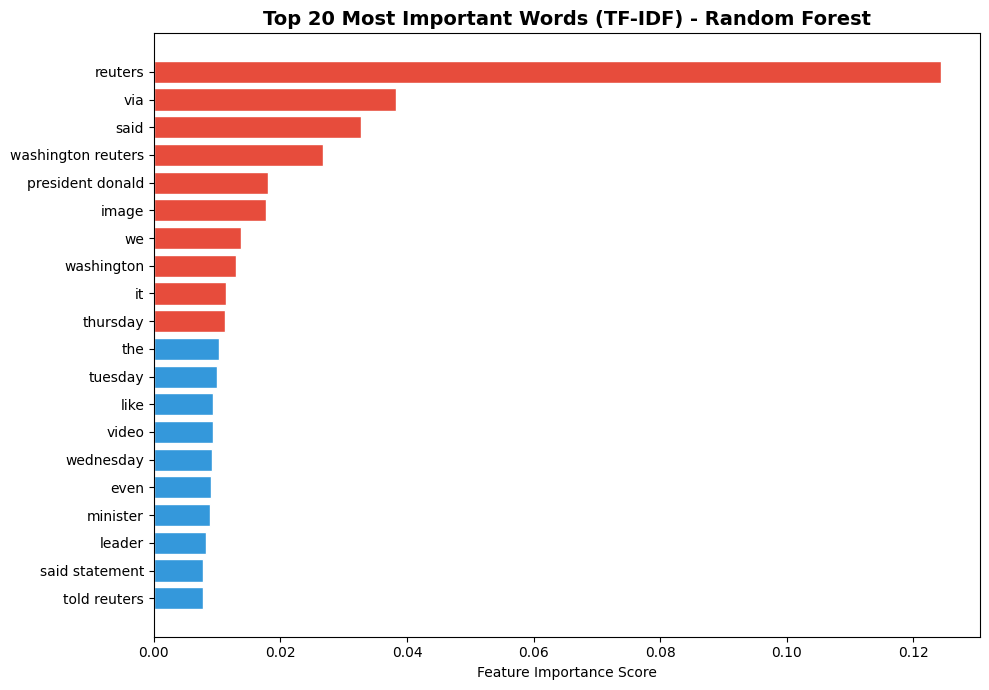

Saved: 08_top_words.png


In [16]:
# Top 20 Most Important TF-IDF Words - Random Forest
feature_names = np.array(tfidf.get_feature_names_out())
importances   = rf_model.feature_importances_
top20_idx     = importances.argsort()[-20:][::-1]
top20_words   = feature_names[top20_idx]
top20_scores  = importances[top20_idx]

plt.figure(figsize=(10, 7))
colors = ['#E74C3C' if s > np.median(top20_scores) else '#3498DB' for s in top20_scores]
plt.barh(top20_words[::-1], top20_scores[::-1], color=colors[::-1], edgecolor='white')
plt.title('Top 20 Most Important Words (TF-IDF) - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('08_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_top_words.png')

Model Comparison & Evaluation

In [17]:
# STEP 8 - Comparison Table
results = pd.DataFrame({
    'Model':     ['Logistic Regression','Decision Tree','Random Forest'],
    'Accuracy':  [lr_acc,  dt_acc,  rf_acc],
    'Precision': [lr_prec, dt_prec, rf_prec],
    'Recall':    [lr_rec,  dt_rec,  rf_rec],
    'F1-Score':  [lr_f1,   dt_f1,   rf_f1]
}).set_index('Model').round(4)

print('='*65)
print('            MODEL COMPARISON TABLE')
print('='*65)
print(results.to_string())
print('='*65)
best = results['F1-Score'].idxmax()
print(f'\nBest Model: {best} (F1={results.loc[best,"F1-Score"]:.4f})')

            MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.9882     0.9919  0.9855    0.9887
Decision Tree          0.9959     0.9972  0.9949    0.9961
Random Forest          0.9953     0.9962  0.9949    0.9955

Best Model: Decision Tree (F1=0.9961)


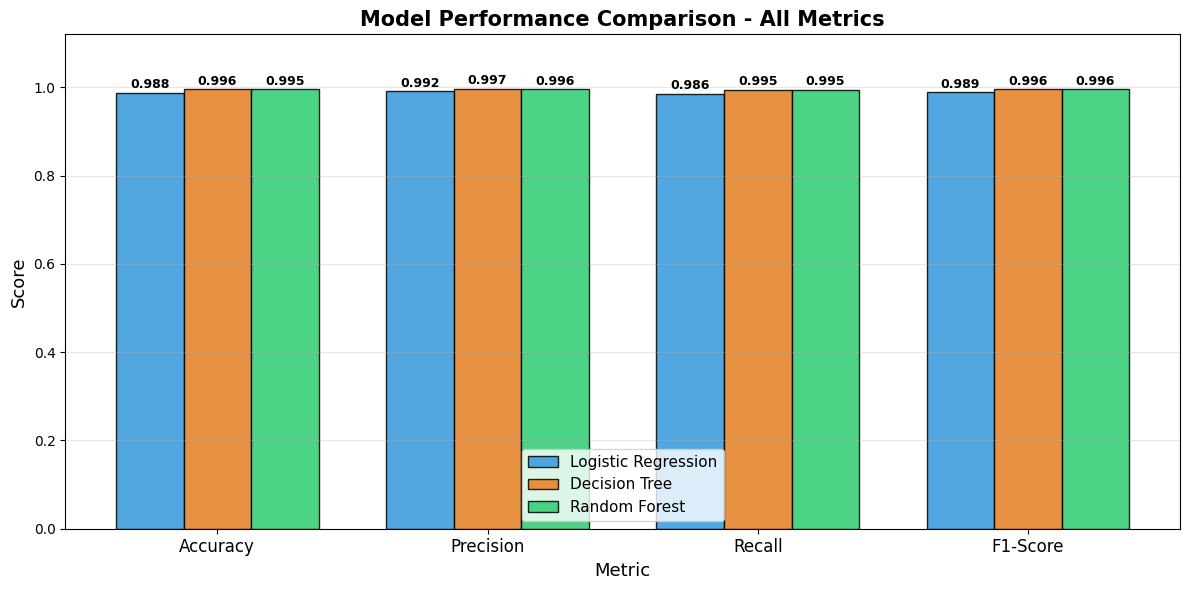

Saved: 09_model_comparison.png


In [18]:
# Grouped Bar Chart - All Metrics
metrics = ['Accuracy','Precision','Recall','F1-Score']
models  = results.index.tolist()
colors  = ['#3498DB','#E67E22','#2ECC71']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))
for i,(model,color) in enumerate(zip(models,colors)):
    vals = results.loc[model, metrics].values
    bars = ax.bar(x+i*width, vals, width, label=model, color=color, edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metric', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Model Performance Comparison - All Metrics', fontsize=15, fontweight='bold')
ax.set_xticks(x+width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 09_model_comparison.png')

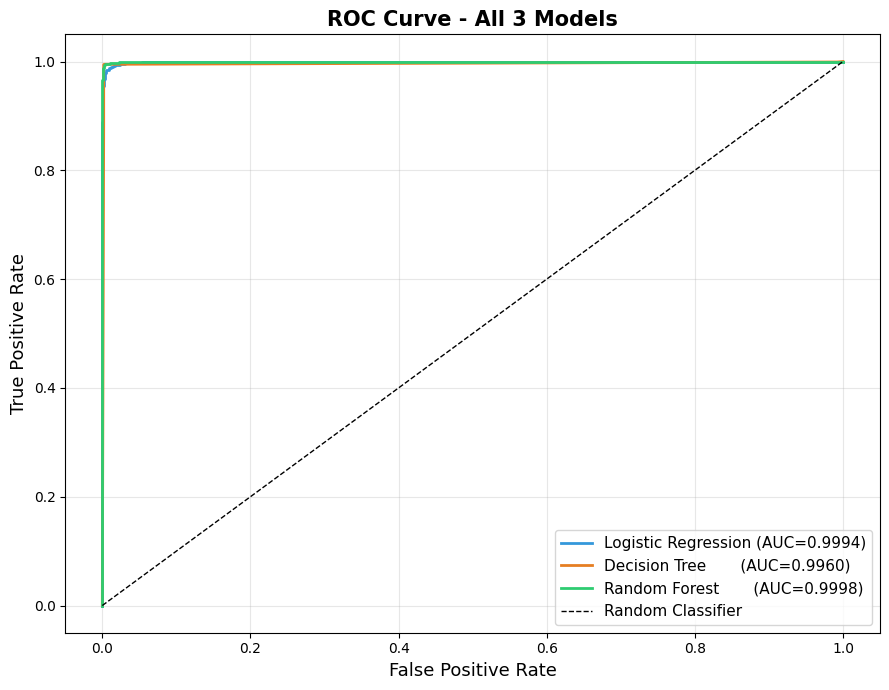

Saved: 10_roc_curves.png


In [19]:
# ROC Curves - All 3 Models
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(9,7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc(fpr_lr,tpr_lr):.4f})', color='#3498DB', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree       (AUC={auc(fpr_dt,tpr_dt):.4f})', color='#E67E22', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest       (AUC={auc(fpr_rf,tpr_rf):.4f})', color='#2ECC71', linewidth=2)
plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate',  fontsize=13)
plt.title('ROC Curve - All 3 Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('10_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 10_roc_curves.png')

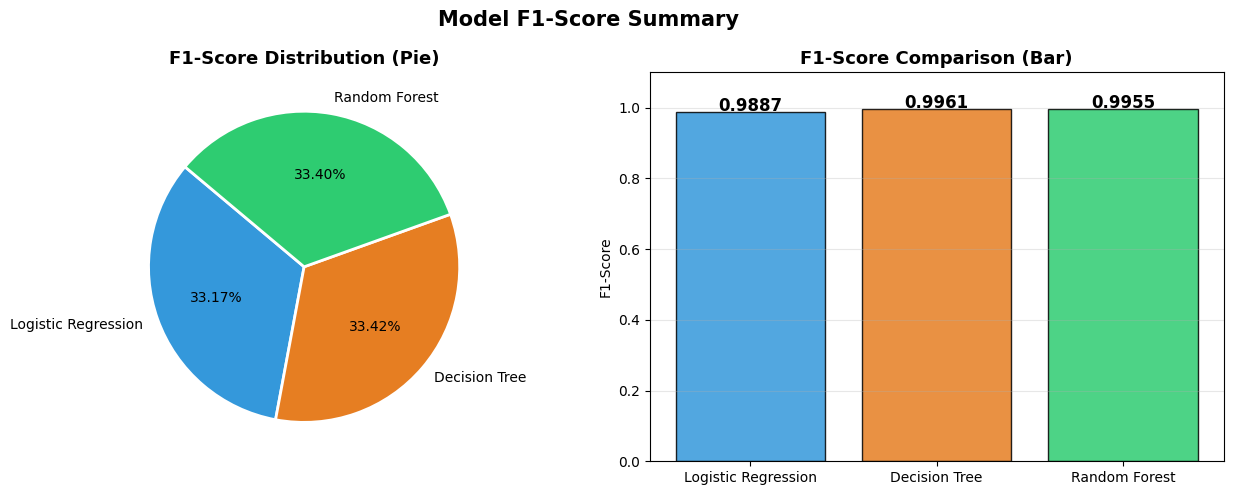

Saved: 11_f1_summary.png


In [20]:
# F1-Score Pie + Bar Summary
f1_scores   = [lr_f1, dt_f1, rf_f1]
model_names = ['Logistic Regression','Decision Tree','Random Forest']
colors_pie  = ['#3498DB','#E67E22','#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].pie(f1_scores, labels=model_names, autopct='%1.2f%%',
    colors=colors_pie, startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('F1-Score Distribution (Pie)', fontsize=13, fontweight='bold')

bars = axes[1].bar(model_names, f1_scores, color=colors_pie, edgecolor='black', alpha=0.85)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
        f'{bar.get_height():.4f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('F1-Score Comparison (Bar)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Model F1-Score Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('11_f1_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 11_f1_summary.png')

Best Model for Deployment


In [21]:
# STEP 9 - Final Verdict
print('='*55)
print('       FINAL MODEL EVALUATION SUMMARY')
print('='*55)
print(results.to_string())
print('='*55)
best = results['F1-Score'].idxmax()
print(f'''
BEST MODEL FOR DEPLOYMENT : {best}
  - Highest F1-Score (best balance of precision & recall)
  - TF-IDF + {best} pipeline ready for deployment
  - Deployment date: April 13, 2026
''')

       FINAL MODEL EVALUATION SUMMARY
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.9882     0.9919  0.9855    0.9887
Decision Tree          0.9959     0.9972  0.9949    0.9961
Random Forest          0.9953     0.9962  0.9949    0.9955

BEST MODEL FOR DEPLOYMENT : Decision Tree
  - Highest F1-Score (best balance of precision & recall)
  - TF-IDF + Decision Tree pipeline ready for deployment
  - Deployment date: April 13, 2026



In [22]:
# Test on a custom news article
sample_fake = "BREAKING: Government secretly controls weather using satellites and 5G towers to manipulate elections!"
sample_real = "The Federal Reserve raised interest rates by 25 basis points on Wednesday, citing persistent inflation concerns."

def predict_news(text, model, vectorizer):
    cleaned = clean_text(text)
    vec     = vectorizer.transform([cleaned])
    pred    = model.predict(vec)[0]
    prob    = model.predict_proba(vec)[0]
    label   = 'FAKE NEWS' if pred == 1 else 'REAL NEWS'
    conf    = max(prob) * 100
    print(f'Text    : {text[:80]}...')
    print(f'Result  : {label}  (Confidence: {conf:.1f}%)')
    print()

print('Testing best model on sample articles:')
print('-'*55)
predict_news(sample_fake, lr_model, tfidf)
predict_news(sample_real, lr_model, tfidf)

Testing best model on sample articles:
-------------------------------------------------------
Text    : BREAKING: Government secretly controls weather using satellites and 5G towers to...
Result  : FAKE NEWS  (Confidence: 73.9%)

Text    : The Federal Reserve raised interest rates by 25 basis points on Wednesday, citin...
Result  : REAL NEWS  (Confidence: 56.2%)

